<a href="https://colab.research.google.com/github/vieweghn/PHYS-330-Optics/blob/main/HW04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

P 4.2

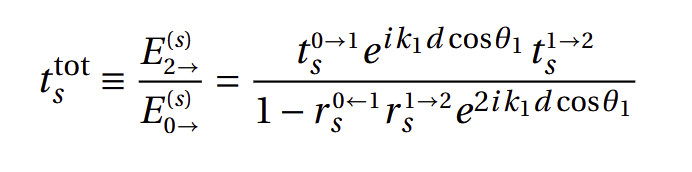
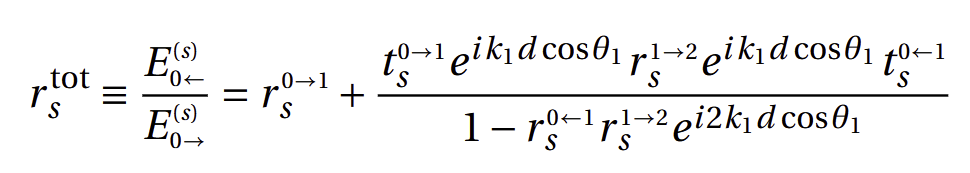

In [ ]:
def alpha(theta_i, nt, ni):
  si = np.sin(theta_i)
  st = ni*si/nt
  theta_t = np.where(st<1.0, np.arcsin(st),1j)
  return np.cos(theta_t)/np.cos(theta_i)

def beta(nt, ni):
  return nt/ni

def rs(theta_i, nt, ni):
  return (1-alpha(theta_i, nt, ni)*beta(nt, ni))/(1+alpha(theta_i, nt, ni)*beta(nt, ni))

def ts(theta_i, nt, ni):
  return 2/(1+alpha(theta_i, nt, ni)*beta(nt, ni))

def rp(theta_i, nt, ni):
  return (alpha(theta_i, nt, ni) - beta(nt, ni))/(alpha(theta_i, nt, ni) + beta(nt, ni))

def tp(theta_i, nt, ni):
  return 2/(alpha(theta_i, nt, ni) + beta(nt, ni))


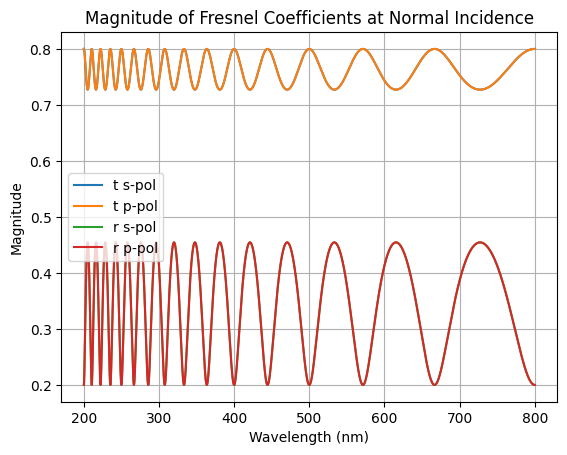

In [9]:
d = 1e-6
n0 = 1 # air
n1 = 2 # dielectric
n2 = 1.5 # glass
lam = np.linspace(200e-9, 800e-9, 10000) # wavelength range from 200 nm to 800 nm

# Plot mag of Frensel coef at normal incidence from air to glass as a function of wavelength
def r_tot(r, t, k, d):
    r0_1 = r[0][0]
    r1_2 = r[0][1]
    r1_0 = r[1][0]
    t0_1 = t[0][0]
    t1_0 = t[1][0]
    return r0_1 + (t0_1 * np.exp(1j * k * d) * r1_2 * np.exp(1j * k * d) * t1_0) / (1 - r1_0 * np.exp(1j * k * d) * r1_2 * np.exp(1j * k * d))

def t_tot(r, t, k, d):
    r0_1 = r[0][0]
    r1_2 = r[0][1]
    r1_0 = r[1][0]
    t0_1 = t[0][0]
    t1_0 = t[1][0]
    t1_2 = t[0][1]
    return (t0_1 * np.exp(1j * k * d) * t1_2) / (1 - r1_0 * np.exp(1j * k * d) * r1_2 * np.exp(1j * k * d))

r_s = np.array([[rs(0, n1, n0), rs(0, n2, n1)],
                [rs(0, n0, n1), rs(0, n1, n2)]])

r_p = np.array([[rp(0, n1, n0), rp(0, n2, n1)],
                [rp(0, n0, n1), rp(0, n1, n2)]])

t_s = np.array([[ts(0, n1, n0), ts(0, n2, n1)],
                [ts(0, n0, n1), ts(0, n1, n2)]])

t_p = np.array([[tp(0, n1, n0), tp(0, n2, n1)],
                [tp(0, n0, n1), tp(0, n1, n2)]])

plt.plot(lam*1e9, np.abs(t_tot(r_s, t_s, n1*2*np.pi/lam, d)), label='t s-pol')
plt.plot(lam*1e9, np.abs(t_tot(r_p, t_p, n1*2*np.pi/lam, d)), label='t p-pol')
plt.plot(lam*1e9, np.abs(r_tot(r_s, t_s, n1*2*np.pi/lam, d)), label='r s-pol')
plt.plot(lam*1e9, np.abs(r_tot(r_p, t_p, n1*2*np.pi/lam, d)), label='r p-pol')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Magnitude')
plt.title('Magnitude of Fresnel Coefficients at Normal Incidence')
plt.legend()
plt.grid()
plt.show()

P 4.4

P 4.8

In [5]:
R = .9
T = .05
A = .05
d = .5e-2
lam = 587e-9
n = 1

Tmax = T**2 / (1 - R)**2
Tmin = T**2 / (1 + R)**2

print(f'a.) Tmax: {Tmax:.2e}, Tmin: {Tmin:.2e}')

dLam_fsr = lam**2 / (2*n*d)

F = 4*R / (1-R)**2
f = np.pi * np.sqrt(F) / 2

dlam_fwhm = dLam_fsr /  f

print(f'b.) FSR: {dLam_fsr:.2e} m, FWHM: {dlam_fwhm:.2e} m')


RP = lam / dlam_fwhm
print(f'c.) Resolving Power: {RP:.2e}')

a.) Tmax: 2.50e-01, Tmin: 6.93e-04
b.) FSR: 3.45e-11 m, FWHM: 1.16e-12 m
c.) Resolving Power: 5.08e+05


P 4.17

In [8]:
def r_mult(n1, n2):
    return ((n2**2 - 1.5 * n1**2) / (n2**2 + 1.5 * n1**2))**2

def r_single(n1):
    return ((1.5 - n1**2) / (1.5 + n1**2))**2

mats = [2.32, 1.63, 1.38]

for i in range(len(mats)):
    j = (i+1) % len(mats)
    r_mult_val_1 = r_mult(mats[i], mats[j])
    r_mult_val_2 = r_mult(mats[j], mats[i])
    r_single_val = r_single(mats[i])
    print(f"Material {i+1} & {j+1}: R_mult = {r_mult_val_1:.4f}")
    print(f"Material {j+1} & {i+1} R_mult_2 = {r_mult_val_2:.4f}")
    print(f"Material {i+1}: R_single = {r_single_val:.4f}")

Material 1 & 2: R_mult = 0.2548
Material 2 & 1 R_mult_2 = 0.0222
Material 1: R_single = 0.3182
Material 2 & 3: R_mult = 0.1248
Material 3 & 2 R_mult_2 = 0.0013
Material 2: R_single = 0.0775
Material 3 & 1: R_mult = 0.0940
Material 1 & 3 R_mult_2 = 0.3823
Material 3: R_single = 0.0141
